<a href="https://colab.research.google.com/github/bahmedx/730/blob/main/Predictive_Modeling_in_Marketing_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Overview**

This Google Colab notebook develops an interpretable customer-retention prediction model using the 'Online Retail II' dataset from the UCI Machine Learning Repository. Historical transaction behavior is converted into customer-level features, and unregularized, L1-regularized, and L2-regularized logistic regression models are compared.

**Imports and Configuration**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Setup complete.")

Setup complete.


**Download and load Online Retail II**

In [ ]:
# Download Online Retail II directly from UCI
!wget -q -O online_retail_II.xlsx \
https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx

print("Loading Online Retail II dataset...")

df = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

print("\nDATA COLLECTION COMPLETE")
print("=" * 50)

print(f"Raw dataset shape: {df.shape}")
print(f"Unique invoices: {df['Invoice'].nunique():,}")
print(f"Unique countries: {df['Country'].nunique():,}")

print(
    f"Date range: {df['InvoiceDate'].min()} "
    f"to {df['InvoiceDate'].max()}"
)

display(df.head())

Loading Online Retail II dataset...

DATA COLLECTION COMPLETE
Raw dataset shape: (525461, 8)
Unique invoices: 28,816
Unique countries: 40
Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,"13,085.0000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,"13,085.0000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom


**Data Quality Assessment**

In [ ]:
quality_summary = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing": df.isnull().sum(),
    "Missing_Percent": (
        df.isnull().mean() * 100
    ).round(2),
    "Unique_Values": df.nunique()
})

print("DATA QUALITY SUMMARY")
display(quality_summary)

print(f"Duplicate rows: {df.duplicated().sum():,}")

print("\nNUMERICAL SUMMARY")
display(
    df[["Quantity", "Price"]]
    .describe()
    .round(2)
)

DATA QUALITY SUMMARY


,Data_Type,Missing,Missing_Percent,Unique_Values
Invoice,object,0,0.0000,28816
StockCode,object,0,0.0000,4632
Description,object,2928,0.5600,4681
Quantity,int64,0,0.0000,825
InvoiceDate,datetime64[ns],0,0.0000,25296
Price,float64,0,0.0000,1606
Customer ID,float64,107927,20.5400,4383
Country,object,0,0.0000,40


Duplicate rows: 6,865

NUMERICAL SUMMARY


,Quantity,Price
count,"525,461.0000","525,461.0000"
mean,10.3400,4.6900
std,107.4200,146.1300
min,"-9,600.0000","-53,594.3600"
25%,1.0000,1.2500
50%,3.0000,2.1000
75%,10.0000,4.2100
max,"19,152.0000","25,111.0900"


**Data Cleaning**

In [ ]:
original_rows = len(df)

# Customer ID is required for customer-level retention modeling
df_clean = df.dropna(
    subset=["Customer ID"]
).copy()

after_customer_id = len(df_clean)

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean["Invoice"]
    .astype(str)
    .str.startswith("C")
].copy()

after_cancellations = len(df_clean)

# Retain economically meaningful purchase transactions
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
].copy()

after_validity = len(df_clean)

# Ensure proper datetime format
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"]
)

# Create transaction-line spending
df_clean["TotalSpend"] = (
    df_clean["Quantity"] *
    df_clean["Price"]
)

print("DATA CLEANING COMPLETE")
print("=" * 50)

print(f"Original rows: {original_rows:,}")

print(
    f"Rows removed for missing Customer ID: "
    f"{original_rows - after_customer_id:,}"
)

print(
    f"Rows removed as cancellations: "
    f"{after_customer_id - after_cancellations:,}"
)

print(
    f"Rows removed for nonpositive Quantity/Price: "
    f"{after_cancellations - after_validity:,}"
)

print(f"Clean dataset shape: {df_clean.shape}")

print(
    f"Unique customers: "
    f"{df_clean['Customer ID'].nunique():,}"
)

print(
    f"Remaining missing Customer IDs: "
    f"{df_clean['Customer ID'].isna().sum()}"
)

print(
    f"Remaining cancelled invoices: "
    f"{df_clean['Invoice'].astype(str).str.startswith('C').sum()}"
)

print(
    f"Remaining invalid quantities: "
    f"{(df_clean['Quantity'] <= 0).sum()}"
)

print(
    f"Remaining invalid prices: "
    f"{(df_clean['Price'] <= 0).sum()}"
)

DATA CLEANING COMPLETE
Original rows: 525,461
Rows removed for missing Customer ID: 107,927
Rows removed as cancellations: 9,839
Rows removed for nonpositive Quantity/Price: 31
Clean dataset shape: (407664, 9)
Unique customers: 4,312
Remaining missing Customer IDs: 0
Remaining cancelled invoices: 0
Remaining invalid quantities: 0
Remaining invalid prices: 0


**Data Preprocessing and Temporal Observation**

In [ ]:
max_date = df_clean["InvoiceDate"].max()

# Reserve the final three months for future retention
split_date = (
    max_date -
    pd.DateOffset(months=3)
)

# Historical information available at prediction time
observation = df_clean[
    df_clean["InvoiceDate"] < split_date
].copy()

# Future period used only to define retention
outcome = df_clean[
    df_clean["InvoiceDate"] >= split_date
].copy()

print("TEMPORAL PREPROCESSING COMPLETE")
print("=" * 50)

print(f"Prediction cutoff: {split_date}")

print(
    f"Observation transactions: "
    f"{len(observation):,}"
)

print(
    f"Outcome transactions: "
    f"{len(outcome):,}"
)

print(
    f"Observation customers: "
    f"{observation['Customer ID'].nunique():,}"
)

print(
    f"Outcome customers: "
    f"{outcome['Customer ID'].nunique():,}"
)

# Verify temporal separation
assert (
    observation["InvoiceDate"].max()
    < split_date
)

assert (
    outcome["InvoiceDate"].min()
    >= split_date
)

print("\nTemporal leakage check passed.")

TEMPORAL PREPROCESSING COMPLETE
Prediction cutoff: 2010-09-09 20:01:00
Observation transactions: 256,539
Outcome transactions: 151,125
Observation customers: 3,373
Outcome customers: 2,885

Temporal leakage check passed.


**Customer Feature Engineering**

In [ ]:
customer_features = observation.groupby("Customer ID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (split_date - x.max()).days
    ),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalSpend", "sum"),
    ItemVariety=("StockCode", "nunique"),
    TotalItems=("Quantity", "sum"),
    FirstPurchase=("InvoiceDate", "min")
)

customer_features["AvgOrderValue"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

customer_features["CustomerTenure"] = (
    split_date -
    customer_features["FirstPurchase"]
).dt.days

customer_features.drop(
    columns="FirstPurchase",
    inplace=True
)

retained_customers = set(outcome["Customer ID"].unique())

customer_features["Retained"] = (
    customer_features.index
    .isin(retained_customers)
    .astype(int)
)

print("Customer modeling dataset:",
      customer_features.shape)

print(
    "Retention rate:",
    f"{customer_features['Retained'].mean():.2%}"
)

display(customer_features.head())
print('\n')
display(customer_features.describe().round(2))

Customer modeling dataset: (3373, 8)
Retention rate: 57.69%


,Recency,Frequency,Monetary,ItemVariety,TotalItems,AvgOrderValue,CustomerTenure,Retained
Customer ID,,,,,,,,
"12,346.0000",73,11,372.8600,26,70,33.8964,269,0
"12,349.0000",114,2,"1,268.5200",47,474,634.2600,133,1
"12,355.0000",111,1,488.2100,22,303,488.2100,111,0
"12,358.0000",94,2,"1,697.9300",34,590,848.9650,275,1
"12,359.0000",79,5,"2,012.0300",82,877,402.4060,278,1


,Recency,Frequency,Monetary,ItemVariety,TotalItems,AvgOrderValue,CustomerTenure,Retained
count,"3,373.0000","3,373.0000","3,373.0000","3,373.0000","3,373.0000","3,373.0000","3,373.0000","3,373.0000"
mean,92.8200,3.6900,"1,680.5500",53.2700,"1,091.0600",368.4200,183.0900,0.5800
std,77.3800,6.2300,"7,303.6500",71.9000,"6,034.9600",458.7500,81.4100,0.4900
min,0.0000,1.0000,2.9500,1.0000,1.0000,2.9500,0.0000,0.0000
25%,27.0000,1.0000,272.9600,15.0000,130.0000,171.7000,121.0000,0.0000
50%,73.0000,2.0000,599.7300,32.0000,325.0000,286.7100,196.0000,1.0000
75%,142.0000,4.0000,"1,427.3600",67.0000,831.0000,416.9200,267.0000,1.0000
max,282.0000,122.0000,"269,041.6700","1,323.0000","220,600.0000","10,953.5000",282.0000,1.0000


**Feature Distribution and Correlation Analysis**

FEATURE DISTRIBUTION ANALYSIS

Feature skewness:


,Skewness
Monetary,23.1900
TotalItems,22.6100
AvgOrderValue,10.8600
Frequency,8.3600
ItemVariety,6.0300
Recency,0.7900
CustomerTenure,-0.4900


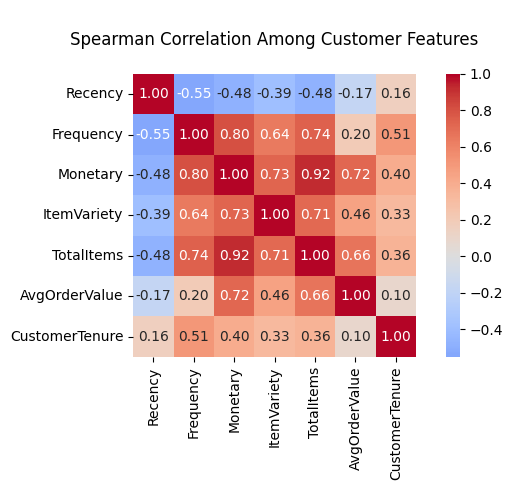


MODEL INPUT VALIDATION
Customer observations: (3373, 7)
Predictive features: 7
Missing predictor values: 0
Retention rate: 57.69%
Target classes: [0, 1]

Feature matrix validation passed.


In [ ]:
# Explicit modeling feature set
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "ItemVariety",
    "TotalItems",
    "AvgOrderValue",
    "CustomerTenure"
]

# Verify that all expected features exist
missing_features = [
    feature
    for feature in feature_columns
    if feature not in customer_features.columns
]

if missing_features:
    raise ValueError(
        "Missing feature(s) in customer_features: "
        + ", ".join(missing_features)
        + ". Re-run Cell 6: Feature Engineering."
    )

# Create modeling feature matrix and target
X = customer_features[
    feature_columns
].copy()

y = customer_features[
    "Retained"
].copy()

# ------------------------------------------------------------
# Feature skewness
# ------------------------------------------------------------

skewness_df = (
    X.skew()
    .sort_values(ascending=False)
    .to_frame("Skewness")
)

print("FEATURE DISTRIBUTION ANALYSIS")
print("=" * 50)

print("\nFeature skewness:")
display(
    skewness_df.round(2)
)

# ------------------------------------------------------------
# Spearman correlation matrix
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    X.corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "\nSpearman Correlation Among Customer Features\n"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("\nMODEL INPUT VALIDATION")
print("=" * 50)

print(f"Customer observations: {X.shape}")

print(
    f"Predictive features: "
    f"{X.shape[1]}"
)

print(
    f"Missing predictor values: "
    f"{X.isnull().sum().sum()}"
)

print(
    f"Retention rate: "
    f"{y.mean():.2%}"
)

print(
    f"Target classes: "
    f"{sorted(y.unique().tolist())}"
)

assert X.shape[1] == 7
assert X.isnull().sum().sum() == 0
assert np.isfinite(X.to_numpy()).all()
assert set(y.unique()).issubset({0, 1})

print("\nFeature matrix validation passed.")

**Train/Holdout Split**

In [ ]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
)

print("TRAIN/HOLDOUT SPLIT")
print("=" * 50)

print(
    f"Training customers: "
    f"{len(X_train):,}"
)

print(
    f"Holdout customers: "
    f"{len(X_test):,}"
)

print(
    f"Training retention rate: "
    f"{y_train.mean():.2%}"
)

print(
    f"Holdout retention rate: "
    f"{y_test.mean():.2%}"
)

assert set(X_train.index).isdisjoint(
    set(X_test.index)
)

print("\nCustomer-level train/holdout separation verified.")

TRAIN/HOLDOUT SPLIT
Training customers: 2,698
Holdout customers: 675
Training retention rate: 57.71%
Holdout retention rate: 57.63%

Customer-level train/holdout separation verified.


**Model Selection and Regularization**

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Candidate inverse regularization strengths
C_grid = np.logspace(
    -4,
    2,
    30
)

# L1 regularized logistic regression
l1_pipeline = Pipeline([
    (
        "scaler",
        RobustScaler()
    ),
    (
        "model",
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE
        )
    )
])

# L2 regularized logistic regression
l2_pipeline = Pipeline([
    (
        "scaler",
        RobustScaler()
    ),
    (
        "model",
        LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=5000,
            random_state=RANDOM_STATE
        )
    )
])

param_grid = {
    "model__C": C_grid
}

print("MODEL SETUP COMPLETE")
print("=" * 50)

print("Models:")
print("  - L1 regularized logistic regression")
print("  - L2 regularized logistic regression")

print(
    f"\nCandidate C values: "
    f"{len(C_grid)}"
)

print(
    f"C range: "
    f"{C_grid.min():.4g} to "
    f"{C_grid.max():.4g}"
)

print(
    "\nCross-validation: "
    "5-fold StratifiedKFold"
)

print(
    "Tuning metric: ROC-AUC"
)

MODEL SETUP COMPLETE
Models:
  - L1 regularized logistic regression
  - L2 regularized logistic regression

Candidate C values: 30
C range: 0.0001 to 100

Cross-validation: 5-fold StratifiedKFold
Tuning metric: ROC-AUC


**Cross-Validation and Hyperparameter Tuning**

In [ ]:
l1_search = GridSearchCV(
    estimator=l1_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

l2_search = GridSearchCV(
    estimator=l2_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

print("Tuning L1 model...")

l1_search.fit(
    X_train,
    y_train
)

print("Tuning L2 model...")

l2_search.fit(
    X_train,
    y_train
)

print("\nCROSS-VALIDATION RESULTS")
print("=" * 50)

print(
    f"L1 optimal C: "
    f"{l1_search.best_params_['model__C']:.5f}"
)

print(
    f"L1 mean CV ROC-AUC: "
    f"{l1_search.best_score_:.4f}"
)

print(
    f"L2 optimal C: "
    f"{l2_search.best_params_['model__C']:.5f}"
)

print(
    f"L2 mean CV ROC-AUC: "
    f"{l2_search.best_score_:.4f}"
)

Tuning L1 model...
Tuning L2 model...

CROSS-VALIDATION RESULTS
L1 optimal C: 0.07880
L1 mean CV ROC-AUC: 0.7212
L2 optimal C: 0.03039
L2 mean CV ROC-AUC: 0.7217


**Unregularized Logistic Regression Baseline**

In [ ]:
baseline_pipeline = Pipeline([
    (
        "scaler",
        RobustScaler()
    ),
    (
        "model",
        LogisticRegression(
            penalty=None,
            solver="lbfgs",
            max_iter=5000,
            random_state=RANDOM_STATE
        )
    )
])

baseline_pipeline.fit(
    X_train,
    y_train
)

print(
    "Unregularized logistic regression "
    "baseline fitted successfully."
)

Unregularized logistic regression baseline fitted successfully.


**Comprehensive Holdout Evaluation**

In [ ]:
models = {
    "Unregularized": baseline_pipeline,
    "L1 (Lasso)": l1_search.best_estimator_,
    "L2 (Ridge)": l2_search.best_estimator_
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

results_df = pd.DataFrame(results).set_index("Model")

display(results_df.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Unregularized,0.6785,0.7299,0.7018,0.7156,0.7485,0.7970
L1 (Lasso),0.6919,0.7388,0.7198,0.7292,0.7519,0.7992
L2 (Ridge),0.6933,0.7370,0.7275,0.7322,0.7520,0.7997


**Classification Reports**

In [ ]:
print("CLASSIFICATION REPORTS")
print("=" * 70)

for name, model in models.items():

    # Generate holdout predictions directly from each pipeline
    y_pred = model.predict(X_test)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Not Retained",
                "Retained"
            ],
            digits=4,
            zero_division=0
        )
    )

CLASSIFICATION REPORTS

Unregularized
              precision    recall  f1-score   support

Not Retained     0.6146    0.6469    0.6303       286
    Retained     0.7299    0.7018    0.7156       389

    accuracy                         0.6785       675
   macro avg     0.6723    0.6743    0.6730       675
weighted avg     0.6811    0.6785    0.6795       675


L1 (Lasso)
              precision    recall  f1-score   support

Not Retained     0.6318    0.6538    0.6426       286
    Retained     0.7388    0.7198    0.7292       389

    accuracy                         0.6919       675
   macro avg     0.6853    0.6868    0.6859       675
weighted avg     0.6934    0.6919    0.6925       675


L2 (Ridge)
              precision    recall  f1-score   support

Not Retained     0.6357    0.6469    0.6412       286
    Retained     0.7370    0.7275    0.7322       389

    accuracy                         0.6933       675
   macro avg     0.6864    0.6872    0.6867       675
weighted avg

**ROC Curves**

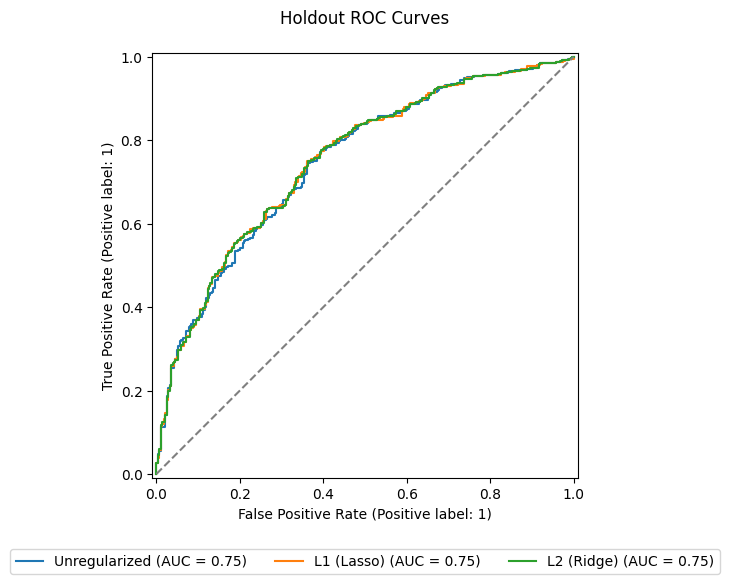

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

ax.set_title("Holdout ROC Curves\n")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()
plt.show()

**Precision-Recall Curves**

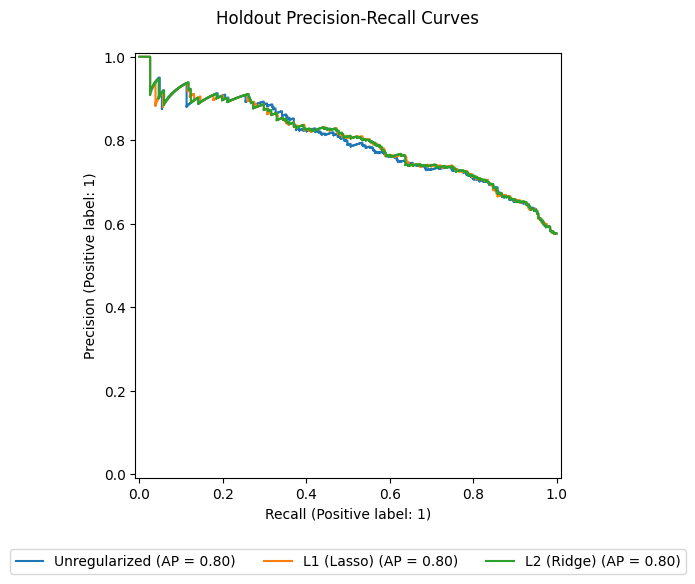

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

ax.set_title("Holdout Precision-Recall Curves\n")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()
plt.show()

**Confusion Matrices**

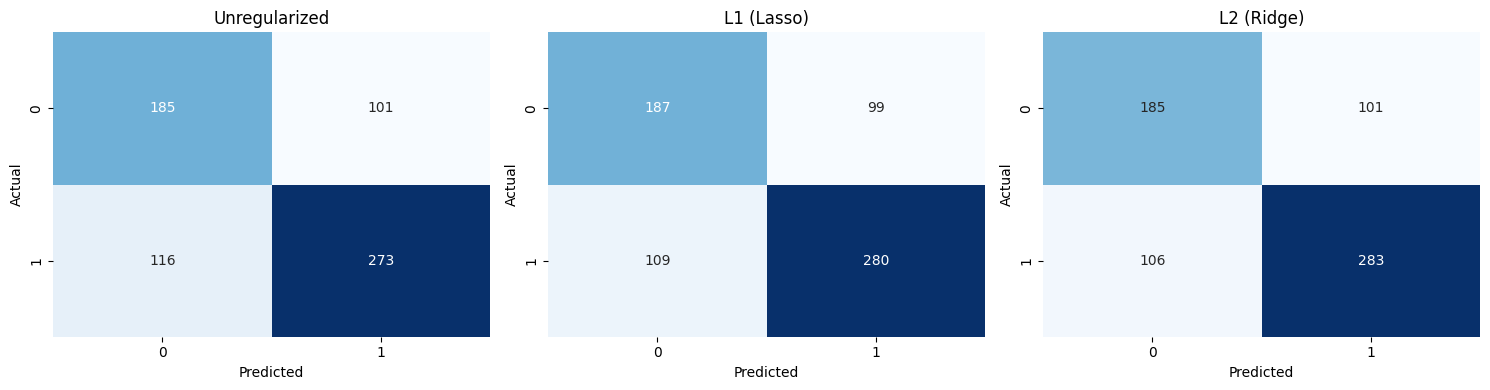

In [ ]:
fig, axes = plt.subplots(
    1,
    len(models),
    figsize=(15, 4)
)

for ax, (name, model) in zip(axes, models.items()):

    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Regularized Coefficient Analysis**

In [ ]:
# Extract fitted regularized models
l1_model = l1_search.best_estimator_.named_steps["model"]
l2_model = l2_search.best_estimator_.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "L1_Coefficient": l1_model.coef_[0],
    "L2_Coefficient": l2_model.coef_[0]
})

# Identify whether L1 retained each feature
coef_df["L1_Selected"] = (
    np.abs(coef_df["L1_Coefficient"]) > 1e-8
)

# Sort features by absolute L1 coefficient magnitude
coef_df["Absolute_L1"] = coef_df["L1_Coefficient"].abs()

coef_df = (
    coef_df
    .sort_values("Absolute_L1", ascending=False)
    .reset_index(drop=True)
)

display(
    coef_df[
        [
            "Feature",
            "L1_Coefficient",
            "L2_Coefficient",
            "L1_Selected"
        ]
    ].round(4)
)

,Feature,L1_Coefficient,L2_Coefficient,L1_Selected
0,Recency,-0.5267,-0.5226,True
1,CustomerTenure,0.4035,0.4078,True
2,ItemVariety,0.3332,0.3346,True
3,Frequency,0.3128,0.2876,True
4,AvgOrderValue,-0.0144,-0.0331,True
5,TotalItems,-0.0040,-0.0060,True
6,Monetary,0.0000,0.0291,False


**Coefficient Visualization**

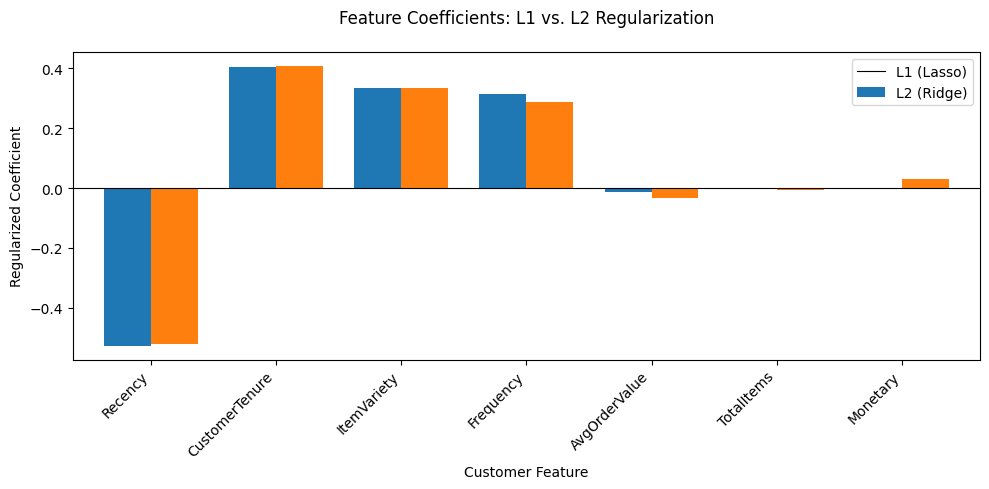

In [ ]:
plot_df = (
    coef_df[
        ["Feature", "L1_Coefficient", "L2_Coefficient"]
    ]
    .set_index("Feature")
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5),
    width=0.75
)

plt.axhline(
    0,
    color="black",
    linewidth=0.8
)

plt.ylabel("Regularized Coefficient")
plt.xlabel("Customer Feature")
plt.title(
    "Feature Coefficients: L1 vs. L2 Regularization\n"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    ["L1 (Lasso)", "L2 (Ridge)"]
)

plt.tight_layout()
plt.show()

**Final Results Summary**

In [ ]:
# 1. Rank models by primary holdout metric

ranked_results = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).copy()

best_model = ranked_results.index[0]
best_auc = ranked_results.iloc[0]["ROC-AUC"]

baseline_auc = results_df.loc[
    "Unregularized", "ROC-AUC"
]

l1_auc = results_df.loc[
    "L1 (Lasso)", "ROC-AUC"
]

l2_auc = results_df.loc[
    "L2 (Ridge)", "ROC-AUC"
]

auc_gap = abs(l1_auc - l2_auc)

best_regularized_auc = max(
    l1_auc,
    l2_auc
)

regularization_gain = (
    best_regularized_auc - baseline_auc
)


# 2. Cross-validation results

l1_c = l1_search.best_params_[
    "model__C"
]

l2_c = l2_search.best_params_[
    "model__C"
]

l1_cv_auc = l1_search.best_score_
l2_cv_auc = l2_search.best_score_


# 3. L1 feature selection

selected_features = coef_df.loc[
    coef_df["L1_Selected"],
    "Feature"
].tolist()

eliminated_features = coef_df.loc[
    ~coef_df["L1_Selected"],
    "Feature"
].tolist()

strongest_positive = coef_df.loc[
    coef_df["L1_Coefficient"].idxmax()
]

strongest_negative = coef_df.loc[
    coef_df["L1_Coefficient"].idxmin()
]

# 4. Create regularization summary table

regularization_summary = pd.DataFrame({
    "Measure": [
        "Unregularized ROC-AUC",
        "L1 ROC-AUC",
        "L2 ROC-AUC",
        "L1-L2 ROC-AUC Gap",
        "Holdout ROC-AUC Gain vs. Baseline"
    ],
    "Value": [
        baseline_auc,
        l1_auc,
        l2_auc,
        auc_gap,
        regularization_gain
    ]
})


# 5. Create cross-validation summary table

cv_summary = pd.DataFrame({
    "Model": [
        "L1 (Lasso)",
        "L2 (Ridge)"
    ],
    "Optimal C": [
        l1_c,
        l2_c
    ],
    "CV ROC-AUC": [
        l1_cv_auc,
        l2_cv_auc
    ]
}).set_index("Model")


# 6. Feature-selection summary

feature_summary = pd.DataFrame({
    "Measure": [
        "Total Features",
        "L1 Features Retained",
        "L1 Features Eliminated",
        "Retained Features",
        "Eliminated Features"
    ],
    "Result": [
        len(coef_df),
        len(selected_features),
        len(eliminated_features),
        ", ".join(selected_features),
        (
            ", ".join(eliminated_features)
            if eliminated_features
            else "None"
        )
    ]
})


# DISPLAY FINAL RESULTS

print("=" * 72)
print("FINAL MODEL RESULTS")
print("=" * 72)


# A. Holdout performance

print("\nA. HOLDOUT MODEL PERFORMANCE\n")

display(
    ranked_results
    .style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
    .highlight_max(
        axis=0,
        color="#d9ead3"
    )
)

# B. Regularization comparison

print("\nB. REGULARIZATION COMPARISON\n")

display(
    regularization_summary
    .style
    .format({
        "Value": "{:.4f}"
    })
)

# C. Cross-validation results

print("\nC. CROSS-VALIDATION RESULTS\n")

display(
    cv_summary
    .style
    .format({
        "Optimal C": "{:.5f}",
        "CV ROC-AUC": "{:.4f}"
    })
    .highlight_max(
        subset=["CV ROC-AUC"],
        color="#d9ead3"
    )
)

# D. L1 feature selection

print("\nD. L1 FEATURE SELECTION\n")

display(
    feature_summary
    .style
    .hide(axis="index")
)

# E. Key coefficient results

print("\nE. KEY COEFFICIENT RESULTS\n")

coefficient_summary = pd.DataFrame({
    "Relationship": [
        "Strongest Positive",
        "Strongest Negative"
    ],
    "Feature": [
        strongest_positive["Feature"],
        strongest_negative["Feature"]
    ],
    "L1 Coefficient": [
        strongest_positive[
            "L1_Coefficient"
        ],
        strongest_negative[
            "L1_Coefficient"
        ]
    ]
})

display(
    coefficient_summary
    .style
    .hide(axis="index")
    .format({
        "L1 Coefficient": "{:.4f}"
    })
)

# F. Concise final findings

print("\nF. KEY FINDINGS\n")

print(
    f"• Highest holdout ROC-AUC: "
    f"{best_model} "
    f"(ROC-AUC = {best_auc:.4f})"
)

print(
    f"• L1 vs. L2 ROC-AUC gap: "
    f"{auc_gap:.4f}"
)

print(
    f"• Holdout ROC-AUC gain vs. unregularized baseline: "
    f"{regularization_gain:+.4f}"
)

print(
    f"• L1 retained "
    f"{len(selected_features)} of "
    f"{len(coef_df)} features"
)

print(
    f"• L1 eliminated: "
    f"{', '.join(eliminated_features) if eliminated_features else 'None'}"
)

print(
    f"• Strongest positive L1 coefficient: "
    f"{strongest_positive['Feature']} "
    f"({strongest_positive['L1_Coefficient']:.4f})"
)

print(
    f"• Strongest negative L1 coefficient: "
    f"{strongest_negative['Feature']} "
    f"({strongest_negative['L1_Coefficient']:.4f})"
)

print("\n" + "=" * 72)
print("MODELING WORKFLOW COMPLETED SUCCESSFULLY")
print("=" * 72)

FINAL MODEL RESULTS

A. HOLDOUT MODEL PERFORMANCE



,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
L2 (Ridge),0.6933,0.7370,0.7275,0.7322,0.7520,0.7997
L1 (Lasso),0.6919,0.7388,0.7198,0.7292,0.7519,0.7992
Unregularized,0.6785,0.7299,0.7018,0.7156,0.7485,0.7970



B. REGULARIZATION COMPARISON



,Measure,Value
0,Unregularized ROC-AUC,0.7485
1,L1 ROC-AUC,0.7519
2,L2 ROC-AUC,0.7520
3,L1-L2 ROC-AUC Gap,0.0001
4,Holdout ROC-AUC Gain vs. Baseline,0.0035



C. CROSS-VALIDATION RESULTS



...


D. L1 FEATURE SELECTION



Measure,Result
Total Features,7
L1 Features Retained,6
L1 Features Eliminated,1
Retained Features,"Recency, CustomerTenure, ItemVariety, Frequency, AvgOrderValue, TotalItems"
Eliminated Features,Monetary



E. KEY COEFFICIENT RESULTS



Relationship,Feature,L1 Coefficient
Strongest Positive,CustomerTenure,0.4035
Strongest Negative,Recency,-0.5267



F. KEY FINDINGS

• Highest holdout ROC-AUC: L2 (Ridge) (ROC-AUC = 0.7520)
• L1 vs. L2 ROC-AUC gap: 0.0001
• Holdout ROC-AUC gain vs. unregularized baseline: +0.0035
• L1 retained 6 of 7 features
• L1 eliminated: Monetary
• Strongest positive L1 coefficient: CustomerTenure (0.4035)
• Strongest negative L1 coefficient: Recency (-0.5267)

MODELING WORKFLOW COMPLETED SUCCESSFULLY
